# hn18~24 통합 EDA (당뇨 불균형 보완)
성인(19세 이상) | 전처리 전 원본 기준

- **hn22~24**: 전체 인구 데이터
- **hn18~21**: 당뇨 유병 행만 추가 (클래스 불균형 보완)

**타겟 코드북**: 1=유병 / 8(해당없음)=정상 / 0·9=제외

## 0. 데이터 로드

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from matplotlib import rc
from scipy import stats
import pyreadstat
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams["axes.unicode_minus"] = False
rc("font", family="AppleGothic")

USE_COLS_SAS = [
    "ID","sex","age","occp","HE_ht","HE_wt","HE_BMI","sm_presnt",
    "BD1_11","BD2_1",
    "HE_HPfh1","HE_HPfh2","HE_HPfh3",
    "HE_DMfh1","HE_DMfh2","HE_DMfh3",
    "HE_HLfh1","HE_HLfh2","HE_HLfh3",
    "BE3_31","BE5_1",
    "DI1_pr","DE1_pr","DI2_pr","HE_obe",
]
COL_RENAME = {
    "sex":"성별","age":"나이","occp":"직업","HE_ht":"키","HE_wt":"체중","HE_BMI":"BMI",
    "sm_presnt":"현재흡연","BD1_11":"음주빈도","BD2_1":"음주량",
    "HE_HPfh1":"고혈압가족력_부","HE_HPfh2":"고혈압가족력_모","HE_HPfh3":"고혈압가족력_형제",
    "HE_DMfh1":"당뇨가족력_부","HE_DMfh2":"당뇨가족력_모","HE_DMfh3":"당뇨가족력_형제",
    "HE_HLfh1":"고지혈증가족력_부","HE_HLfh2":"고지혈증가족력_모","HE_HLfh3":"고지혈증가족력_형제",
    "BE3_31":"걷기일수","BE5_1":"근력운동일수",
    "DI1_pr":"고혈압유병","DE1_pr":"당뇨유병","DI2_pr":"이상지질혈증유병","HE_obe":"비만단계",
}
INT_COLS = [
    "성별","나이","직업","현재흡연","음주빈도","음주량","걷기일수","근력운동일수",
    "고혈압유병","당뇨유병","이상지질혈증유병","비만단계",
    "고혈압가족력_부","고혈압가족력_모","고혈압가족력_형제",
    "당뇨가족력_부","당뇨가족력_모","당뇨가족력_형제",
    "고지혈증가족력_부","고지혈증가족력_모","고지혈증가족력_형제",
]

# ── 경로 수정 ──────────────────────────────────────────
DATA_DIR = "/Users/admin/PycharmProjects/AH_03_03/ai_worker/data"
# ──────────────────────────────────────────────────────

# ── hn22~24: 전체 인구 로드 ────────────────────────────
PATHS = {
    2022: f"{DATA_DIR}/hn22_all.sas7bdat",
    2023: f"{DATA_DIR}/hn23_all.sas7bdat",
    2024: f"{DATA_DIR}/hn24_all.sas7bdat",
}

dfs = []
for year, path in PATHS.items():
    df_tmp, _ = pyreadstat.read_sas7bdat(path, usecols=USE_COLS_SAS)
    df_tmp = df_tmp.rename(columns=COL_RENAME)
    for c in INT_COLS:
        if c in df_tmp.columns:
            df_tmp[c] = pd.to_numeric(df_tmp[c], errors="coerce")
    df_tmp = df_tmp[df_tmp["나이"] >= 19].reset_index(drop=True)
    df_tmp = df_tmp.drop(columns=["ID"])
    df_tmp["연도"] = year
    dfs.append(df_tmp)
    print(f"hn{year} 로드 완료 | shape: {df_tmp.shape}")

# 타겟 이진화 (hn22~24)
df_main = pd.concat(dfs, ignore_index=True)
for col in ["고혈압유병","당뇨유병","이상지질혈증유병"]:
    df_main[col] = df_main[col].map({1.0:1, 1:1, 8.0:0, 8:0})

# ── hn18~21: 당뇨 유병 행만 추가 ──────────────────────
DM_PATHS = {
    2021: f"{DATA_DIR}/hn21_diabetes_DE1pr.csv",
    2020: f"{DATA_DIR}/hn20_diabetes_DE1pr.csv",
    2019: f"{DATA_DIR}/hn19_diabetes_DE1pr.csv",
    2018: f"{DATA_DIR}/hn18_diabetes_DE1pr.csv",
}

dfs_dm = []
for year, path in DM_PATHS.items():
    df_tmp = pd.read_csv(path, usecols=USE_COLS_SAS)
    df_tmp = df_tmp.rename(columns=COL_RENAME)
    for c in INT_COLS:
        if c in df_tmp.columns:
            df_tmp[c] = pd.to_numeric(df_tmp[c], errors="coerce")
    df_tmp = df_tmp[df_tmp["나이"] >= 19].reset_index(drop=True)
    df_tmp = df_tmp.drop(columns=["ID"], errors="ignore")
    df_tmp["연도"] = year
    for col in ["고혈압유병","당뇨유병","이상지질혈증유병"]:
        df_tmp[col] = df_tmp[col].map({1.0:1, 1:1, 8.0:0, 8:0})
    dfs_dm.append(df_tmp)
    print(f"hn{year} 당뇨 유병 추가 | shape: {df_tmp.shape}")

df_dm_add = pd.concat(dfs_dm, ignore_index=True)

# ── 최종 통합 ──────────────────────────────────────────
df = pd.concat([df_main, df_dm_add], ignore_index=True)

print(f"\n통합 shape: {df.shape}")
print(f"연도별 샘플: {df['연도'].value_counts().sort_index().to_dict()}")
print("\n=== 당뇨 불균형 확인 ===")
for col in ["고혈압유병","당뇨유병","이상지질혈증유병"]:
    vc = df[col].value_counts()
    n0, n1 = vc.get(0,0), vc.get(1,0)
    print(f"{col}: 정상 {n0:,} / 유병 {n1:,} / 불균형 1:{n0/n1:.1f}")
df.head()


hn2022 로드 완료 | shape: (5322, 25)
hn2023 로드 완료 | shape: (5907, 25)
hn2024 로드 완료 | shape: (6033, 25)
hn2021 당뇨 유병 추가 | shape: (665, 25)
hn2020 당뇨 유병 추가 | shape: (661, 25)
hn2019 당뇨 유병 추가 | shape: (605, 25)
hn2018 당뇨 유병 추가 | shape: (572, 25)

통합 shape: (19765, 25)
연도별 샘플: {2018: 572, 2019: 605, 2020: 661, 2021: 665, 2022: 5322, 2023: 5907, 2024: 6033}

=== 당뇨 불균형 확인 ===
고혈압유병: 정상 13,213 / 유병 6,277 / 불균형 1:2.1
당뇨유병: 정상 15,062 / 유병 4,657 / 불균형 1:3.2
이상지질혈증유병: 정상 13,732 / 유병 5,443 / 불균형 1:2.5


,성별,나이,직업,고혈압유병,이상지질혈증유병,당뇨유병,음주빈도,음주량,현재흡연,걷기일수,...,고지혈증가족력_모,고지혈증가족력_형제,당뇨가족력_부,당뇨가족력_모,당뇨가족력_형제,키,체중,BMI,비만단계,연도
0,2.0,56.0,7.0,1.0,0.0,0.0,1.0,8.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,151.2,60.6,26.507517,4.0,2022
1,1.0,30.0,3.0,0.0,0.0,0.0,3.0,2.0,0.0,8.0,...,0.0,0.0,1.0,0.0,0.0,174.1,82.3,27.152029,4.0,2022
2,2.0,25.0,7.0,0.0,0.0,0.0,4.0,1.0,0.0,8.0,...,1.0,0.0,1.0,0.0,0.0,166.4,59.0,21.308131,2.0,2022
3,1.0,66.0,7.0,0.0,1.0,0.0,3.0,2.0,0.0,8.0,...,0.0,0.0,0.0,0.0,0.0,168.7,67.1,23.577207,3.0,2022
4,2.0,62.0,6.0,0.0,1.0,0.0,2.0,1.0,0.0,8.0,...,0.0,1.0,0.0,0.0,1.0,157.1,53.9,21.839183,2.0,2022


## 1. 기본 통계량

In [26]:
cont_cols = ["나이","키","체중","BMI"]
summary = pd.DataFrame({
    "N":        df[cont_cols].count(),
    "결측수":    df[cont_cols].isnull().sum(),
    "결측률(%)": (df[cont_cols].isnull().sum()/len(df)*100).round(1),
    "평균":      df[cont_cols].mean().round(2),
    "중앙값":    df[cont_cols].median().round(2),
    "표준편차":  df[cont_cols].std().round(2),
    "최솟값":    df[cont_cols].min().round(2),
    "최댓값":    df[cont_cols].max().round(2),
    "왜도":      df[cont_cols].skew().round(3),
    "첨도":      df[cont_cols].kurt().round(3),
})
print("=== 연속형 변수 기술통계 ===")
print(summary.T)


=== 연속형 변수 기술통계 ===
               나이          키         체중        BMI
N       19765.000  19389.000  19639.000  19384.000
결측수         0.000    376.000    126.000    381.000
결측률(%)      0.000      1.900      0.600      1.900
평균         55.400    163.120     64.740     24.230
중앙값        58.000    162.800     63.100     23.900
표준편차       16.850      9.320     13.140      3.760
최솟값        19.000    127.900     25.000     12.070
최댓값        80.000    194.000    147.000     48.680
왜도         -0.375      0.099      0.861      0.767
첨도         -0.876     -0.402      1.432      1.600


## 2. 연도별 샘플 분포

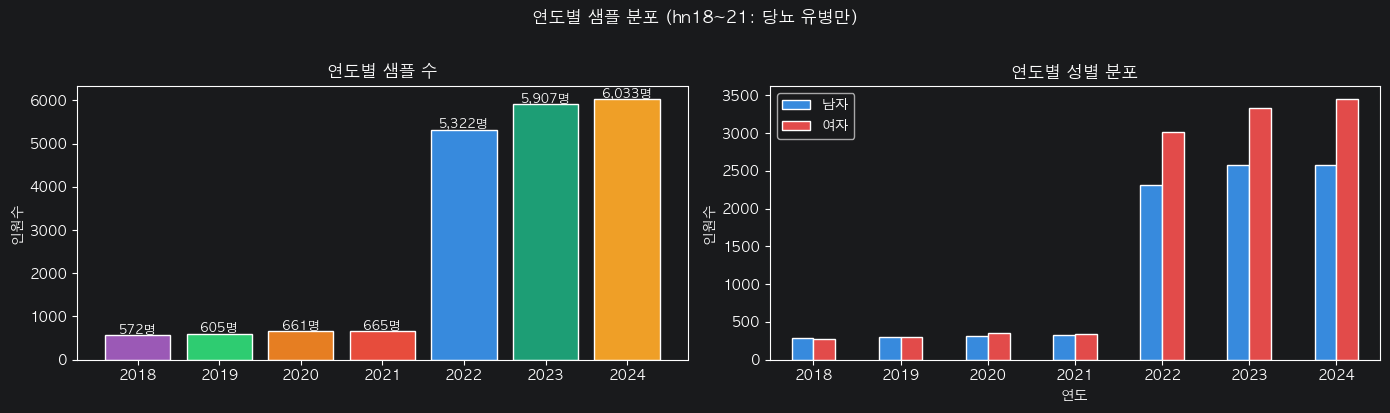

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vc = df["연도"].value_counts().sort_index()
colors_yr = ["#9B59B6","#2ECC71","#E67E22","#E74C3C","#378ADD","#1D9E75","#EF9F27"]
axes[0].bar(vc.index.astype(str), vc.values, color=colors_yr[:len(vc)], edgecolor="white")
axes[0].set_title("연도별 샘플 수"); axes[0].set_ylabel("인원수")
for i, (idx, val) in enumerate(vc.items()):
    axes[0].text(i, val+30, f"{val:,}명", ha="center", fontsize=9)

gender_ct = df.groupby(["연도","성별"]).size().unstack(fill_value=0)
gender_ct.columns = ["남자","여자"]
gender_ct.plot(kind="bar", ax=axes[1], color=["#378ADD","#E24B4A"], edgecolor="white", rot=0)
axes[1].set_title("연도별 성별 분포"); axes[1].set_ylabel("인원수"); axes[1].legend()

plt.suptitle("연도별 샘플 분포 (hn18~21: 당뇨 유병만)", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


## 3. Y값(타겟) 분포
> **0=정상 / 1=유병 / NaN=제외**
>
> ⚠️ hn18~21은 당뇨 유병 행만 포함 → 연도별 분포는 hn22~24만 해석

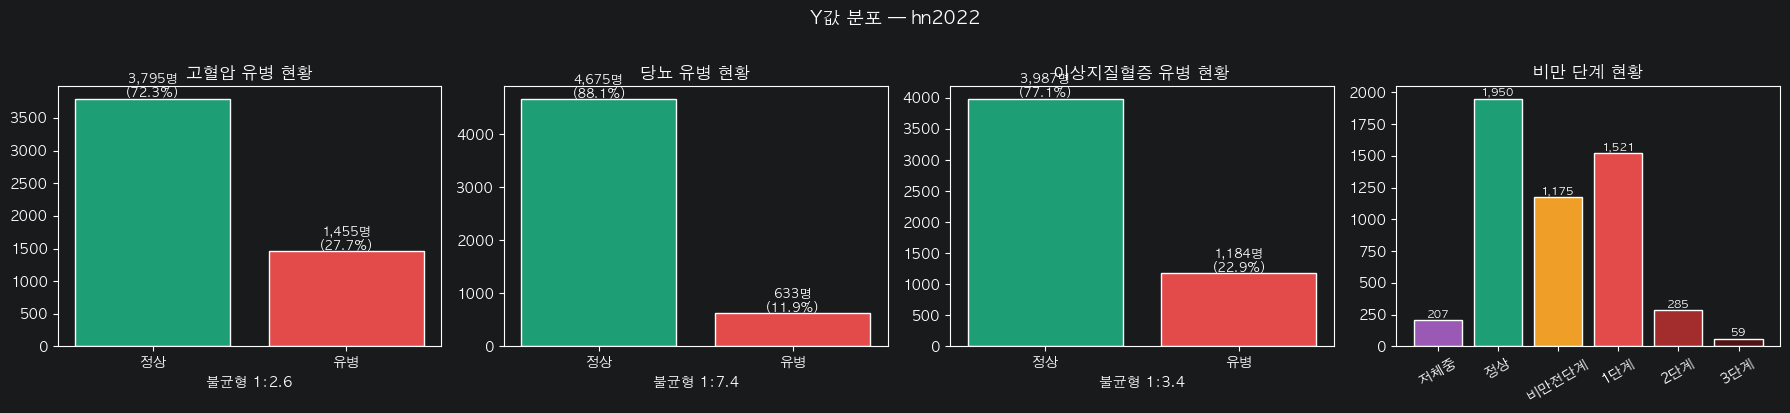

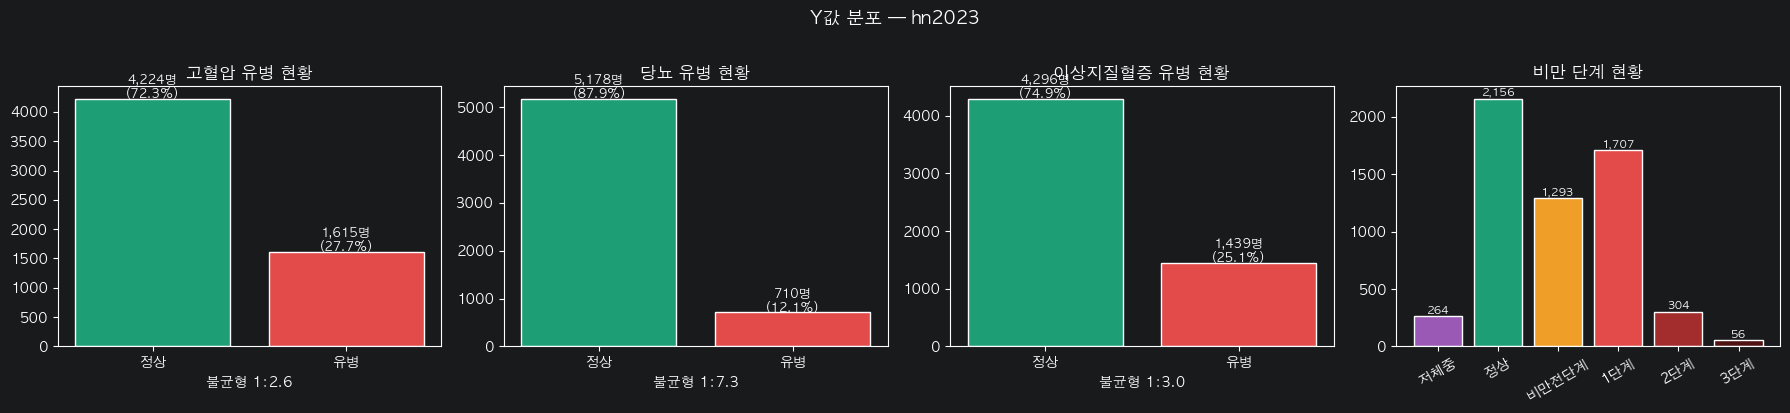

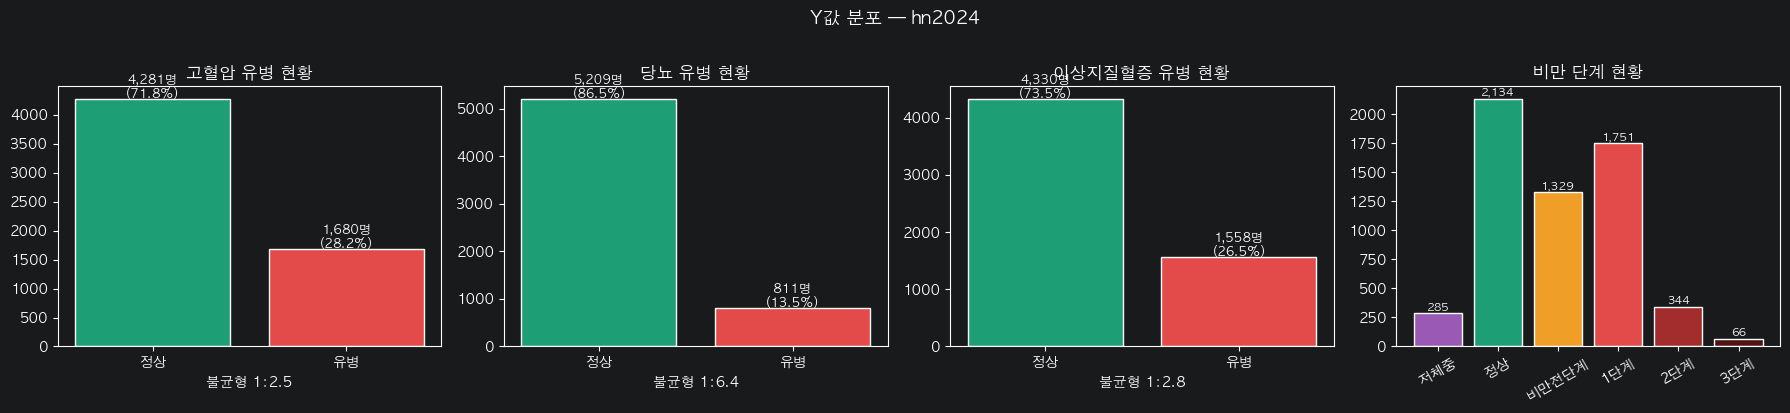

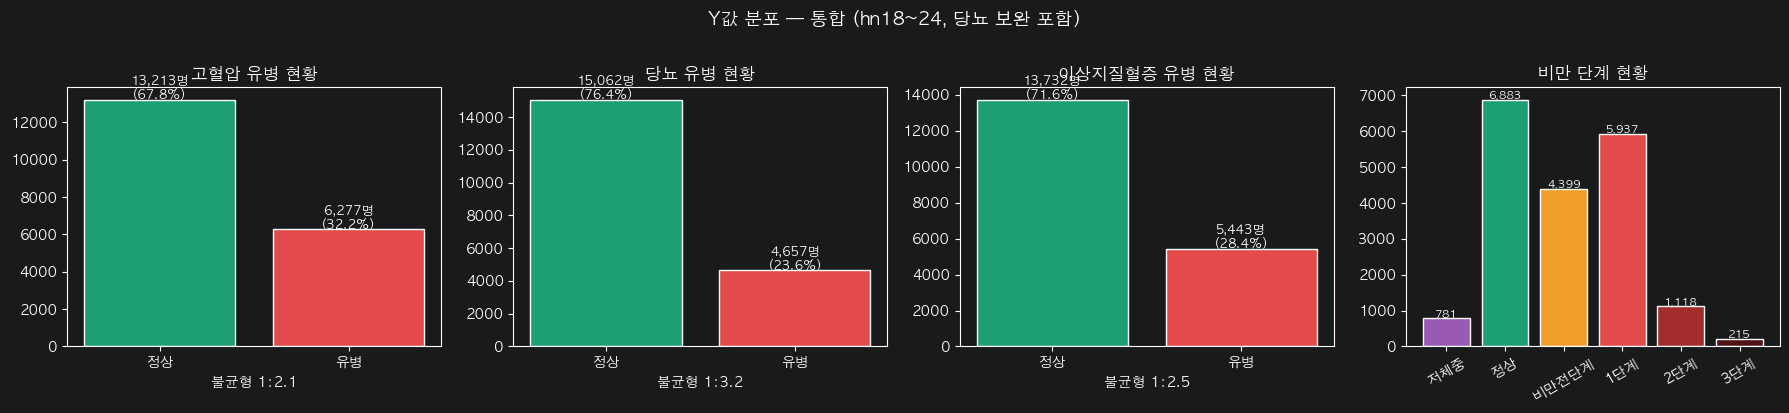

In [28]:
def plot_y_dist(data, title_suffix=""):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, col, title in zip(
        axes[:3],
        ["고혈압유병","당뇨유병","이상지질혈증유병"],
        ["고혈압","당뇨","이상지질혈증"]
    ):
        vc = data[col].value_counts().sort_index()
        n_total = vc.sum()
        bars = ax.bar(["정상","유병"], vc.values, color=["#1D9E75","#E24B4A"], edgecolor="white")
        ax.set_title(f"{title} 유병 현황")
        for bar, val in zip(bars, vc.values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                    f"{val:,}명\n({val/n_total*100:.1f}%)", ha="center", fontsize=9)
        n1=vc.get(1,0); n0=vc.get(0,0)
        ax.set_xlabel(f"불균형 1:{n0/n1:.1f}" if n1>0 else "")
    obe = data["비만단계"].value_counts().sort_index().dropna()
    obe_labels = {1:"저체중",2:"정상",3:"비만전단계",4:"1단계",5:"2단계",6:"3단계"}
    obe.index = [obe_labels.get(int(i), str(i)) for i in obe.index]
    axes[3].bar(obe.index, obe.values,
                color=["#9B59B6","#1D9E75","#EF9F27","#E24B4A","#A32D2D","#501313"],
                edgecolor="white")
    axes[3].set_title("비만 단계 현황")
    axes[3].tick_params(axis="x", rotation=30)
    for i, v in enumerate(obe.values):
        axes[3].text(i, v+20, f"{v:,}", ha="center", fontsize=8)
    plt.suptitle(f"Y값 분포 {title_suffix}", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

# 연도별 (hn22~24만 — 전체 인구 기준)
for year in [2022, 2023, 2024]:
    plot_y_dist(df[df["연도"]==year], f"— hn{year}")

# 전체 통합 (hn18~24)
plot_y_dist(df, "— 통합 (hn18~24, 당뇨 보완 포함)")


## 4. 연속형 변수 분포

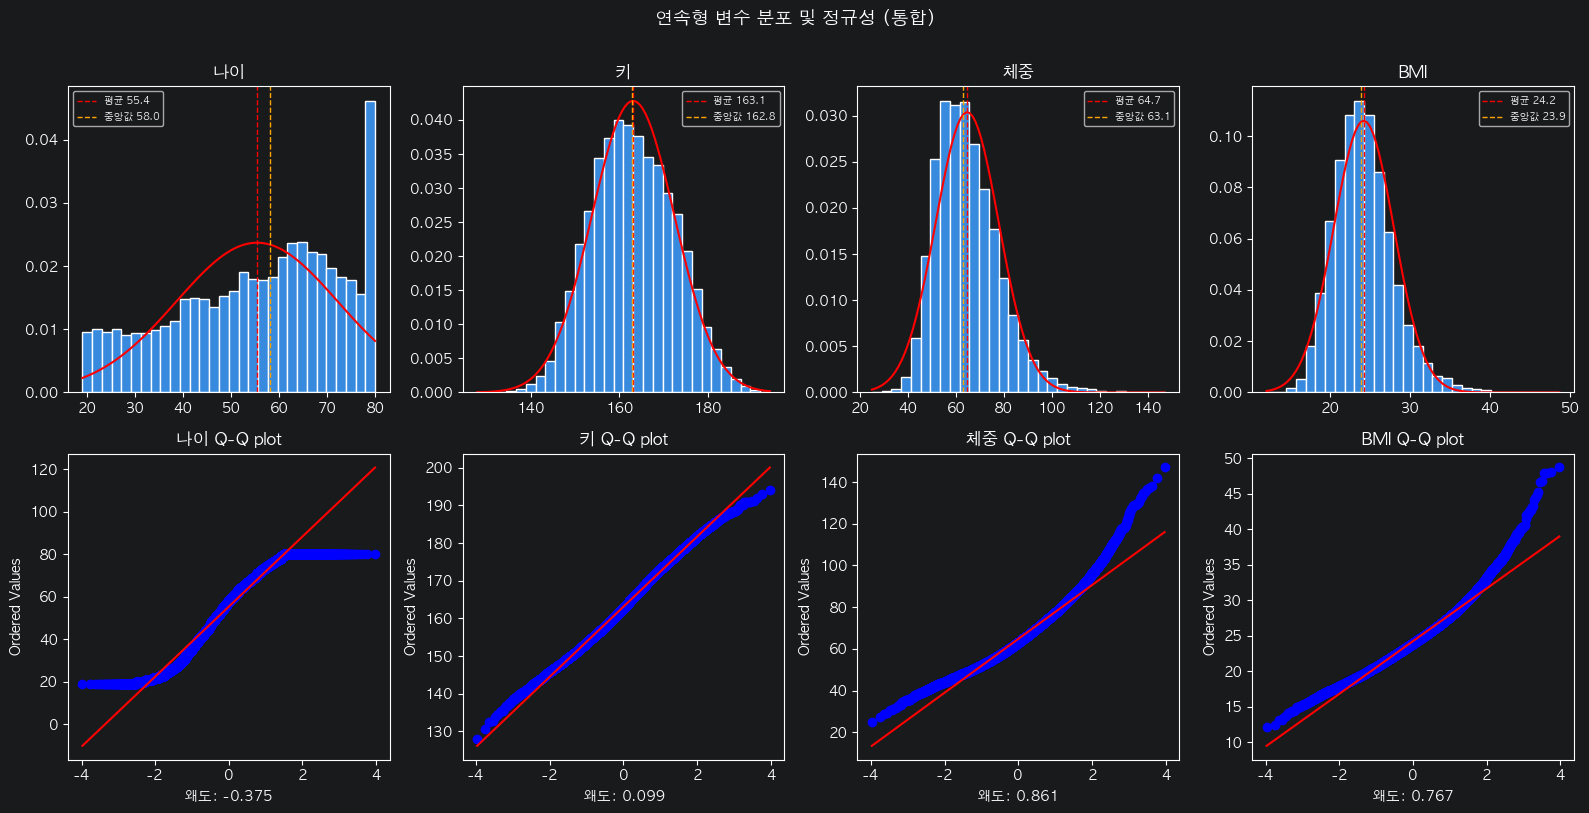

In [29]:
cont_cols = ["나이","키","체중","BMI"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for j, col in enumerate(cont_cols):
    data = df[col].dropna()
    mu, std = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    axes[0][j].hist(data, bins=30, color="#378ADD", edgecolor="white", density=True)
    axes[0][j].plot(x, stats.norm.pdf(x, mu, std), "r-", lw=1.5)
    axes[0][j].axvline(mu, color="red", ls="--", lw=1, label=f"평균 {mu:.1f}")
    axes[0][j].axvline(data.median(), color="orange", ls="--", lw=1, label=f"중앙값 {data.median():.1f}")
    axes[0][j].set_title(col); axes[0][j].legend(fontsize=7)
    stats.probplot(data, dist="norm", plot=axes[1][j])
    axes[1][j].set_title(f"{col} Q-Q plot")
    axes[1][j].set_xlabel(f"왜도: {data.skew():.3f}")

plt.suptitle("연속형 변수 분포 및 정규성 (통합)", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## 5. 범주형 변수 분포

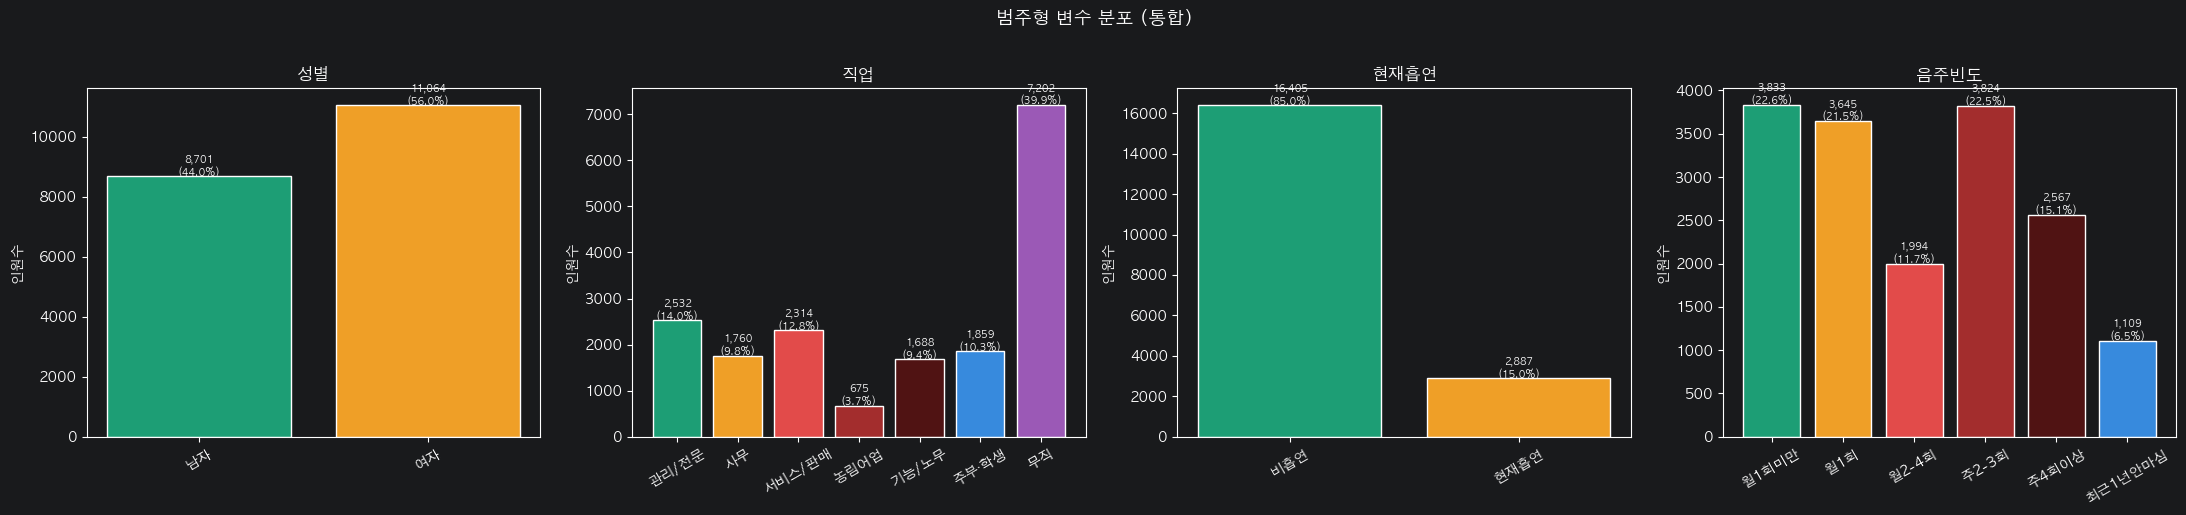

In [30]:
cat_cols = {
    "성별":     {1:"남자", 2:"여자"},
    "직업":     {1:"관리/전문",2:"사무",3:"서비스/판매",4:"농림어업",5:"기능/노무",6:"주부·학생",7:"무직"},
    "현재흡연": {0:"비흡연", 1:"현재흡연"},
    "음주빈도": {0:"비음주",1:"월1회미만",2:"월1회",3:"월2-4회",4:"주2-3회",5:"주4회이상",6:"최근1년안마심"},
}
colors = ["#1D9E75","#EF9F27","#E24B4A","#A32D2D","#501313","#378ADD","#9B59B6","#2ECC71"]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (col, labels) in zip(axes, cat_cols.items()):
    vc = df[col].value_counts(dropna=True).sort_index()
    vc = vc[vc.index.isin(labels.keys())]
    new_index = [labels.get(i, str(i)) for i in vc.index]
    pct = (vc/vc.sum()*100).round(1)
    bars = ax.bar(new_index, vc.values, color=colors[:len(vc)], edgecolor="white")
    ax.set_title(col, fontsize=12); ax.set_ylabel("인원수"); ax.tick_params(axis="x", rotation=30)
    for bar, val, p in zip(bars, vc.values, pct.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                f"{val:,}\n({p}%)", ha="center", fontsize=7)

plt.suptitle("범주형 변수 분포 (통합)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


## 6. Y값별 연속형 비교 (boxplot)

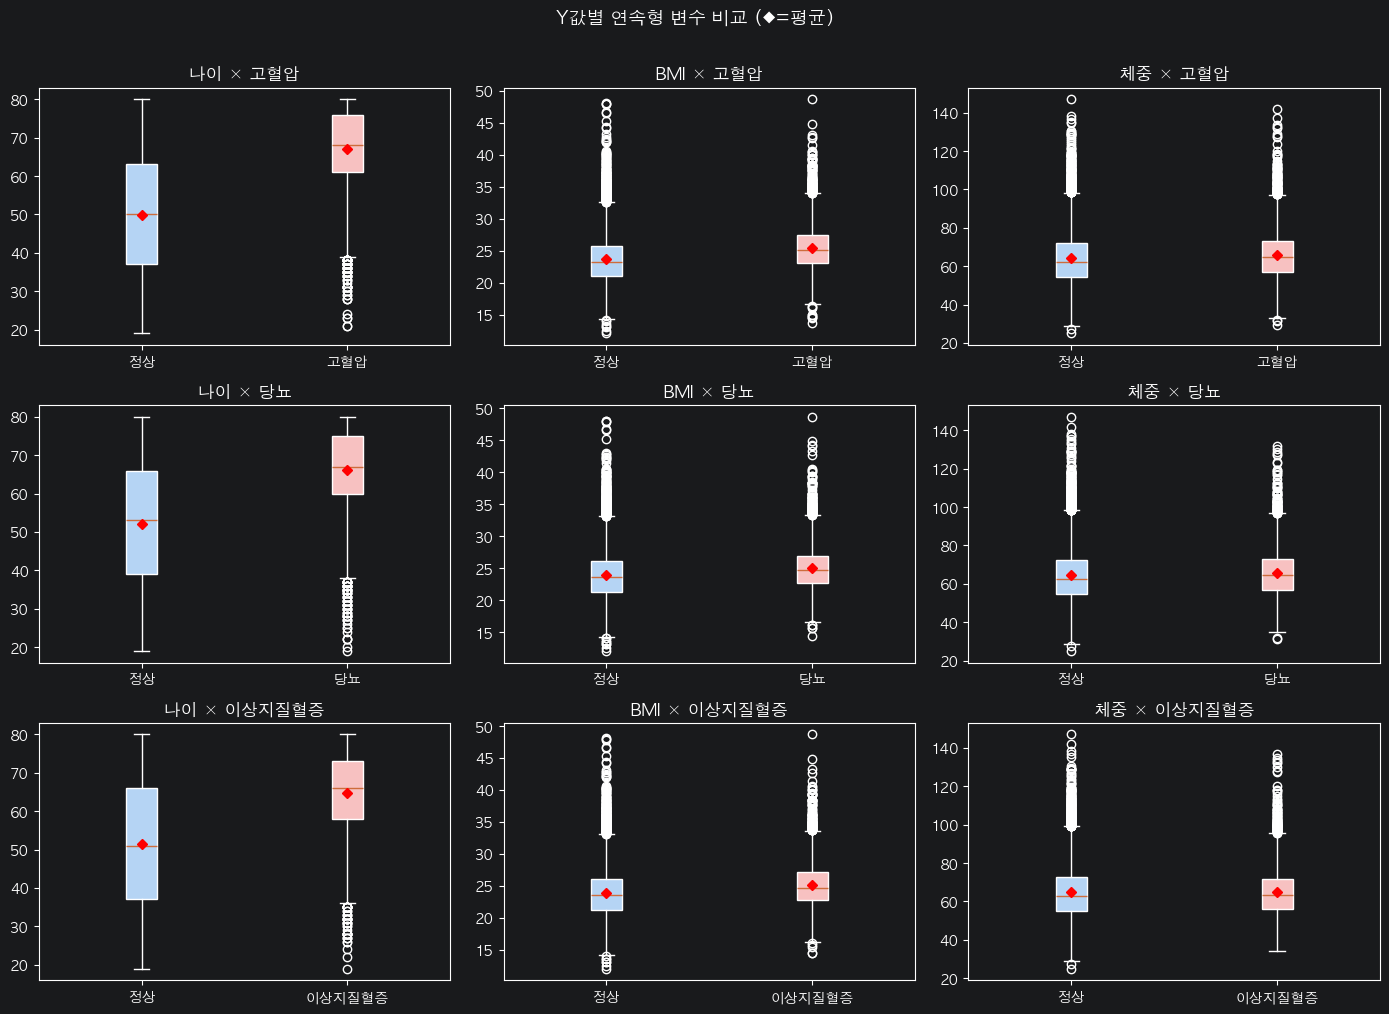

In [31]:
y_vars = {"고혈압유병":"고혈압", "당뇨유병":"당뇨", "이상지질혈증유병":"이상지질혈증"}
x_vars = ["나이","BMI","체중"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for i, (y_col, y_label) in enumerate(y_vars.items()):
    for j, x_col in enumerate(x_vars):
        d0 = df[df[y_col]==0][x_col].dropna()
        d1 = df[df[y_col]==1][x_col].dropna()
        bp = axes[i][j].boxplot([d0,d1], labels=["정상",y_label], patch_artist=True)
        bp["boxes"][0].set_facecolor("#B5D4F4")
        bp["boxes"][1].set_facecolor("#F7C1C1")
        axes[i][j].set_title(f"{x_col} × {y_label}")
        for k, d in enumerate([d0,d1]):
            axes[i][j].plot(k+1, d.mean(), "D", color="red", ms=5, zorder=5)

plt.suptitle("Y값별 연속형 변수 비교 (◆=평균)", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## 7. 결측률 분석

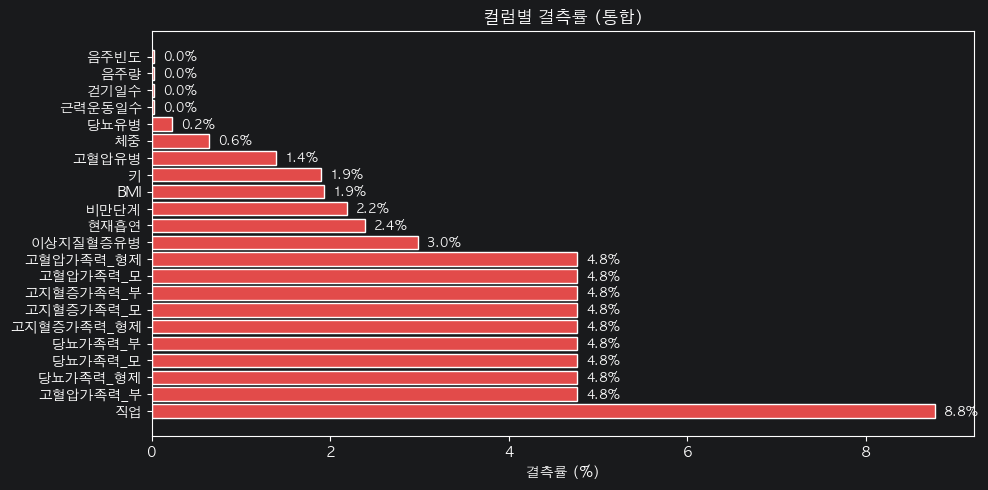

=== 결측률 상세 ===
직업            8.78
고혈압가족력_부      4.77
당뇨가족력_형제      4.77
당뇨가족력_모       4.77
당뇨가족력_부       4.77
고지혈증가족력_형제    4.77
고지혈증가족력_모     4.77
고지혈증가족력_부     4.77
고혈압가족력_모      4.77
고혈압가족력_형제     4.77
이상지질혈증유병      2.99
현재흡연          2.39
비만단계          2.19
BMI           1.93
키             1.90
고혈압유병         1.39
체중            0.64
당뇨유병          0.23
근력운동일수        0.03
걷기일수          0.03
음주량           0.03
음주빈도          0.03
dtype: float64


In [32]:
miss_pct = (df.isnull().sum()/len(df)*100).round(2)
miss_pct = miss_pct[miss_pct>0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(miss_pct.index, miss_pct.values, color="#E24B4A", edgecolor="white")
ax.set_xlabel("결측률 (%)"); ax.set_title("컬럼별 결측률 (통합)")
for bar, val in zip(bars, miss_pct.values):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout(); plt.show()
print("=== 결측률 상세 ===")
print(miss_pct)


## 8. 가족력 보유율

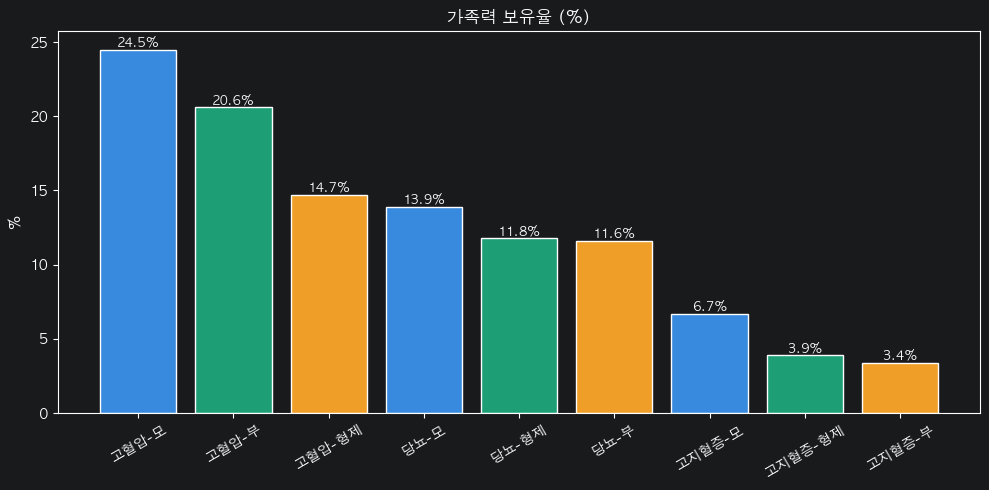

In [33]:
fh_cols = {
    "고혈압가족력_부":"고혈압-부","고혈압가족력_모":"고혈압-모","고혈압가족력_형제":"고혈압-형제",
    "당뇨가족력_부":"당뇨-부","당뇨가족력_모":"당뇨-모","당뇨가족력_형제":"당뇨-형제",
    "고지혈증가족력_부":"고지혈증-부","고지혈증가족력_모":"고지혈증-모","고지혈증가족력_형제":"고지혈증-형제",
}
fh_rate = {}
for col, label in fh_cols.items():
    vc = df[col].value_counts(dropna=True)
    n1 = vc.get(1.0, vc.get(1, 0))
    fh_rate[label] = round(n1/vc.sum()*100, 1) if vc.sum()>0 else 0

fh_series = pd.Series(fh_rate).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(fh_series.index, fh_series.values,
              color=["#378ADD","#1D9E75","#EF9F27"]*3, edgecolor="white")
ax.set_title("가족력 보유율 (%)"); ax.set_ylabel("%"); ax.tick_params(axis="x", rotation=30)
for bar, val in zip(bars, fh_series.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f"{val}%", ha="center", fontsize=9)
plt.tight_layout(); plt.show()


## 9. 연도별 유병률 추이
> ⚠️ hn18~21은 당뇨 유병만 포함 → 당뇨 유병률 100%, 참고용으로만 볼 것
> hn22~24 추이만 해석 권장

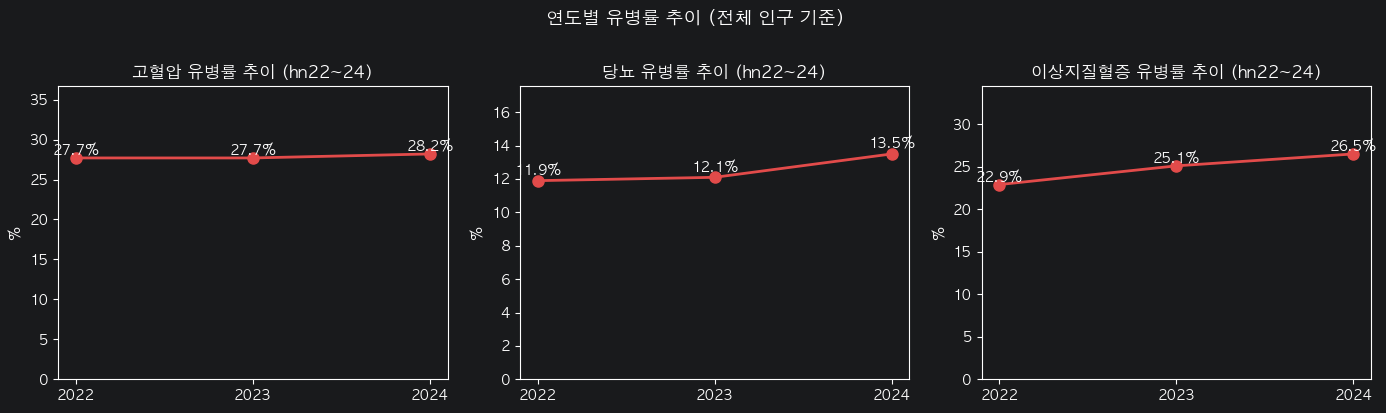

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
y_info = [("고혈압유병","고혈압"),("당뇨유병","당뇨"),("이상지질혈증유병","이상지질혈증")]

for ax, (col, label) in zip(axes, y_info):
    # hn22~24만 추이 표시
    trend = df[df["연도"].isin([2022,2023,2024])].groupby("연도")[col].apply(
        lambda x: (x==1).sum()/x.notna().sum()*100
    ).round(1)
    ax.plot(trend.index, trend.values, "o-", color="#E24B4A", lw=2, ms=8)
    ax.set_title(f"{label} 유병률 추이 (hn22~24)"); ax.set_ylabel("%"); ax.set_xticks(trend.index)
    for x_val, y_val in zip(trend.index, trend.values):
        ax.text(x_val, y_val+0.3, f"{y_val:.1f}%", ha="center", fontsize=10)
    ax.set_ylim(0, trend.max()*1.3)

plt.suptitle("연도별 유병률 추이 (전체 인구 기준)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


## 10. 상관관계 히트맵

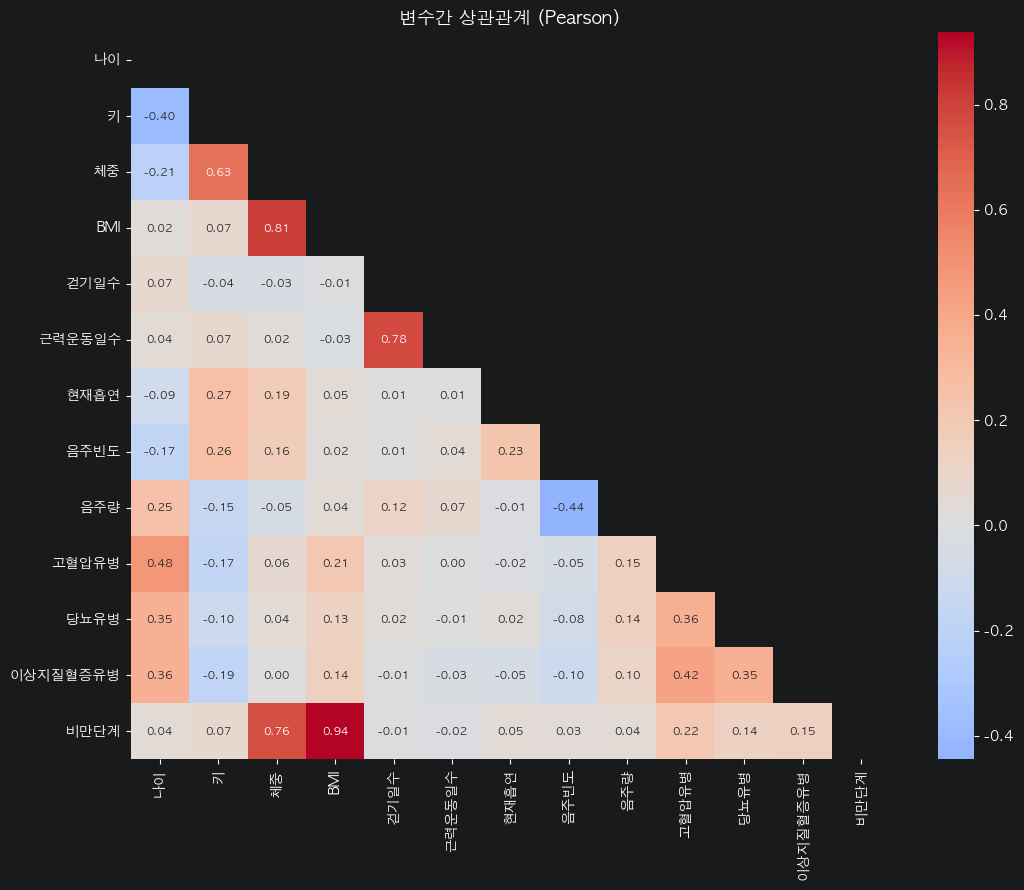

In [35]:
corr_cols = ["나이","키","체중","BMI","걷기일수","근력운동일수",
             "현재흡연","음주빈도","음주량",
             "고혈압유병","당뇨유병","이상지질혈증유병","비만단계"]

df_corr = df[corr_cols].copy()
df_corr["음주빈도"] = df_corr["음주빈도"].where(~df_corr["음주빈도"].isin([8,9]), other=np.nan)

corr = df_corr.corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, annot_kws={"size":8})
ax.set_title("변수간 상관관계 (Pearson)", fontsize=13)
plt.tight_layout(); plt.show()


## 11. 전처리 및 통합 CSV 저장
> 베이스라인 LightGBM 입력용 — 직업 OHE, NaN 유지

In [36]:
# ── 전처리 및 통합 CSV 저장 ─────────────────────────────────
# v2 베이스라인 기준:
#   - 직업: OHE (직업_관리전문, 직업_사무, 직업_서비스판매, 직업_농림어업,
#            직업_기능노무, 직업_주부학생, 직업_작업미상, 직업_무직)
#   - 성별: 그대로 (1=남, 2=여)
#   - 나머지 수치형: NaN 그대로 (LightGBM이 자체 처리)
#   - 타겟: 이미 이진화 완료 (0/1/NaN)

import os

SAVE_DIR  = DATA_DIR  # EDA와 같은 경로
SAVE_PATH = os.path.join(SAVE_DIR, 'hn_all_preprocessed.csv')

df_pp = df.copy()

# ── 직업 OHE ─────────────────────────────────────────────────
occp_map = {
    1: '관리전문', 2: '사무', 3: '서비스판매',
    4: '농림어업', 5: '기능노무', 6: '주부학생',
    7: '무직',
}
# 유효값만 OHE (NaN, 기타값은 모든 더미=0)
for key, label in occp_map.items():
    df_pp[f'직업_{label}'] = (df_pp['직업'] == key).astype(int)

# 직업_작업미상: 1~7 외 값 (결측 제외)
df_pp['직업_작업미상'] = (
    df_pp['직업'].notna() & ~df_pp['직업'].isin(occp_map.keys())
).astype(int)

# 원본 직업 컬럼 제거
df_pp = df_pp.drop(columns=['직업'])

# ── 최종 컬럼 순서 정리 ──────────────────────────────────────
target_cols   = ['고혈압유병', '당뇨유병', '이상지질혈증유병']
drop_cols_pp  = ['비만단계', '연도', '연령대'] if '연령대' in df_pp.columns else ['비만단계', '연도']
feature_cols  = [c for c in df_pp.columns if c not in target_cols + drop_cols_pp]

df_save = df_pp[feature_cols + target_cols].copy()

df_save.to_csv(SAVE_PATH, index=False, encoding='utf-8-sig')

print(f'[전처리] 저장 완료: {SAVE_PATH}')
print(f'[전처리] shape: {df_save.shape}')
print(f'[전처리] 컬럼 목록:')
for c in df_save.columns:
    print(f'  - {c}')
print()
print('[전처리] 타겟 분포')
for col in target_cols:
    vc = df_save[col].value_counts(dropna=False)
    n0, n1 = vc.get(0.0, 0), vc.get(1.0, 0)
    nan = df_save[col].isna().sum()
    print(f'  {col}: 정상={n0:,} / 유병={n1:,} / NaN={nan:,} / 불균형 1:{n0/n1:.1f}')


[전처리] 저장 완료: /Users/admin/PycharmProjects/AH_03_03/ai_worker/data/hn_all_preprocessed.csv
[전처리] shape: (19765, 30)
[전처리] 컬럼 목록:
  - 성별
  - 나이
  - 음주빈도
  - 음주량
  - 현재흡연
  - 걷기일수
  - 근력운동일수
  - 고혈압가족력_부
  - 고혈압가족력_모
  - 고혈압가족력_형제
  - 고지혈증가족력_부
  - 고지혈증가족력_모
  - 고지혈증가족력_형제
  - 당뇨가족력_부
  - 당뇨가족력_모
  - 당뇨가족력_형제
  - 키
  - 체중
  - BMI
  - 직업_관리전문
  - 직업_사무
  - 직업_서비스판매
  - 직업_농림어업
  - 직업_기능노무
  - 직업_주부학생
  - 직업_무직
  - 직업_작업미상
  - 고혈압유병
  - 당뇨유병
  - 이상지질혈증유병

[전처리] 타겟 분포
  고혈압유병: 정상=13,213 / 유병=6,277 / NaN=275 / 불균형 1:2.1
  당뇨유병: 정상=15,062 / 유병=4,657 / NaN=46 / 불균형 1:3.2
  이상지질혈증유병: 정상=13,732 / 유병=5,443 / NaN=590 / 불균형 1:2.5


In [37]:
# ── hn22~24 전처리 CSV 저장 (베이스라인 비교용) ──────────────
SAVE_PATH_2224 = os.path.join(DATA_DIR, 'hn2224_preprocessed.csv')

# df_main = hn22~24 전체 인구 (이미 메모리에 있음)
df_pp2 = df_main.copy()

# 직업 OHE
occp_map = {1:'관리전문',2:'사무',3:'서비스판매',4:'농림어업',5:'기능노무',6:'주부학생',7:'무직'}
for key, label in occp_map.items():
    df_pp2[f'직업_{label}'] = (df_pp2['직업'] == key).astype(int)
df_pp2['직업_작업미상'] = (df_pp2['직업'].notna() & ~df_pp2['직업'].isin(occp_map.keys())).astype(int)
df_pp2 = df_pp2.drop(columns=['직업'])

# 불필요 컬럼 제거
target_cols = ['고혈압유병','당뇨유병','이상지질혈증유병']
drop_pp = [c for c in ['비만단계','연도','연령대'] if c in df_pp2.columns]
feature_cols = [c for c in df_pp2.columns if c not in target_cols + drop_pp]
df_pp2 = df_pp2[feature_cols + target_cols]

df_pp2.to_csv(SAVE_PATH_2224, index=False, encoding='utf-8-sig')
print(f'저장 완료: {SAVE_PATH_2224}')
print(f'shape: {df_pp2.shape}')
for col in target_cols:
    vc = df_pp2[col].value_counts(dropna=False)
    n0,n1 = vc.get(0.0,0), vc.get(1.0,0)
    print(f'  {col}: 정상={n0:,} / 유병={n1:,} / 불균형 1:{n0/n1:.1f}')

저장 완료: /Users/admin/PycharmProjects/AH_03_03/ai_worker/data/hn2224_preprocessed.csv
shape: (17262, 30)
  고혈압유병: 정상=12,300 / 유병=4,750 / 불균형 1:2.6
  당뇨유병: 정상=15,062 / 유병=2,154 / 불균형 1:7.0
  이상지질혈증유병: 정상=12,613 / 유병=4,181 / 불균형 1:3.0
